# Exploratory Data Analysis — Credit Card Fraud Detection

Exploring the class imbalance, transaction amount patterns, and feature correlations before building the model pipeline.

In [8]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_raw_data, get_class_distribution

sns.set_style("whitegrid")
%matplotlib inline

df = load_raw_data()
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Class Distribution

The core challenge of this dataset: how rare is fraud, exactly?

Normal transactions: 284,315 (99.8273%)
Fraud transactions:  492 (0.1727%)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13496\2633787840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Normal", "Fraud"])


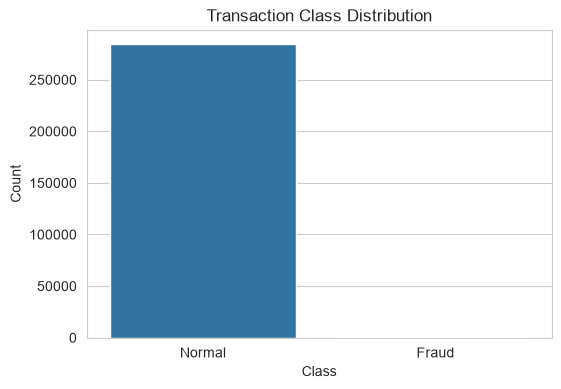

In [9]:
class_counts = df["Class"].value_counts()
class_pct = get_class_distribution(df)

print(f"Normal transactions: {class_counts[0]:,} ({class_pct[0]:.4%})")
print(f"Fraud transactions:  {class_counts[1]:,} ({class_pct[1]:.4%})")

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x="Class", data=df, ax=ax)
ax.set_xticklabels(["Normal", "Fraud"])
ax.set_title("Transaction Class Distribution")
ax.set_ylabel("Count")
plt.show()

The class imbalance is severe — fraud makes up only ~0.17% of all transactions. This means accuracy alone is a misleading metric; a model predicting "not fraud" every time would still score ~99.8% accuracy.

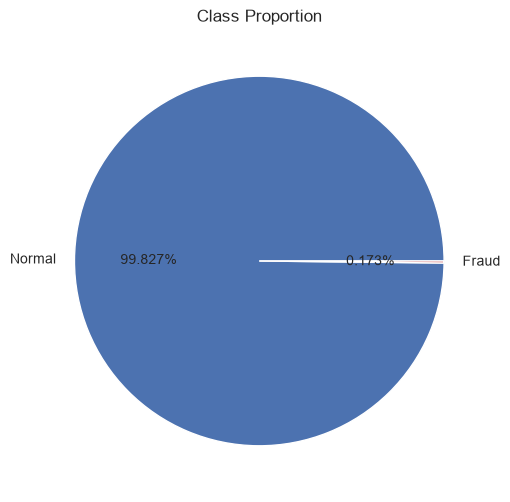

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
class_counts.plot.pie(
    labels=["Normal", "Fraud"],
    autopct="%1.3f%%",
    colors=["#4C72B0", "#C44E52"],
    ax=ax,
)
ax.set_ylabel("")
ax.set_title("Class Proportion")
plt.show()

## 2. Transaction Amount Analysis

Do fraudulent transactions tend to involve different amounts than normal ones?

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13496\3872202660.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Normal", "Fraud"])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13496\3872202660.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Normal", "Fraud"])


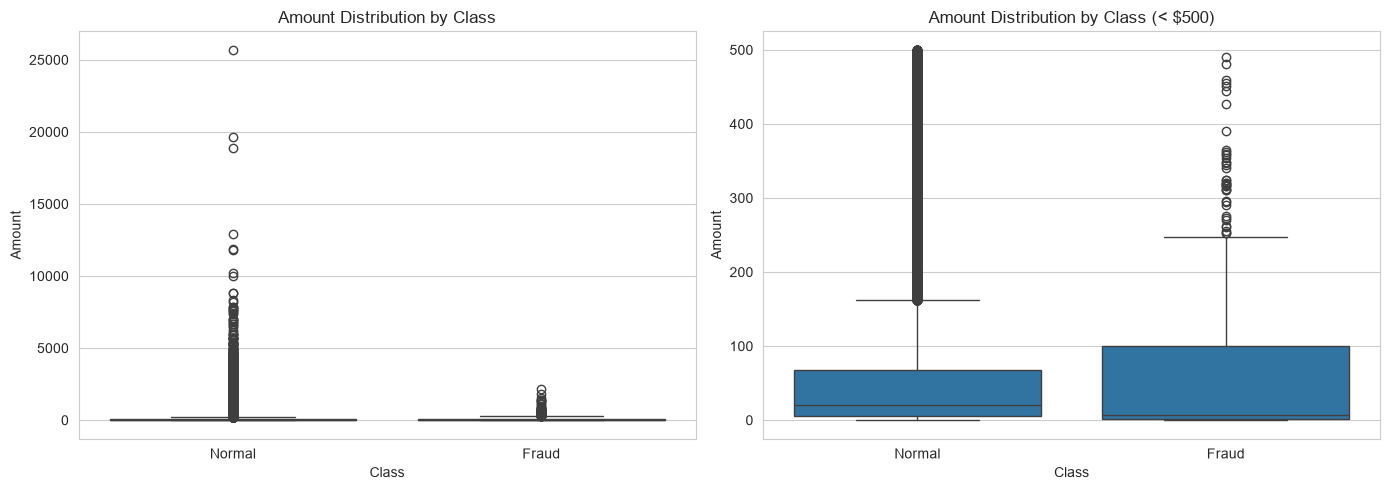

In [11]:
print(df.groupby("Class")["Amount"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="Class", y="Amount", data=df, ax=axes[0])
axes[0].set_xticklabels(["Normal", "Fraud"])
axes[0].set_title("Amount Distribution by Class")

# Zoom in to exclude extreme outliers for a clearer view
sns.boxplot(x="Class", y="Amount", data=df[df["Amount"] < 500], ax=axes[1])
axes[1].set_xticklabels(["Normal", "Fraud"])
axes[1].set_title("Amount Distribution by Class (< $500)")

plt.tight_layout()
plt.show()

## 3. Transaction Time Analysis

The `Time` column represents seconds elapsed since the first transaction in the dataset. Does fraud cluster at certain times?

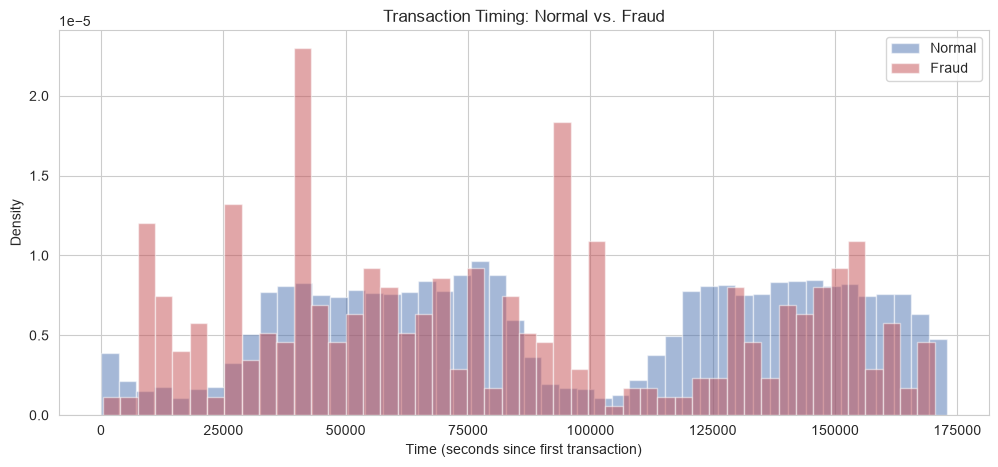

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

for label, name, color in [(0, "Normal", "#4C72B0"), (1, "Fraud", "#C44E52")]:
    subset = df[df["Class"] == label]
    ax.hist(subset["Time"], bins=48, alpha=0.5, label=name, color=color, density=True)

ax.set_xlabel("Time (seconds since first transaction)")
ax.set_ylabel("Density")
ax.set_title("Transaction Timing: Normal vs. Fraud")
ax.legend()
plt.show()

## 4. Feature Correlation with Fraud

The dataset's `V1`-`V28` columns are PCA-transformed for privacy. Let's see which of these anonymized features correlate most strongly with fraud.

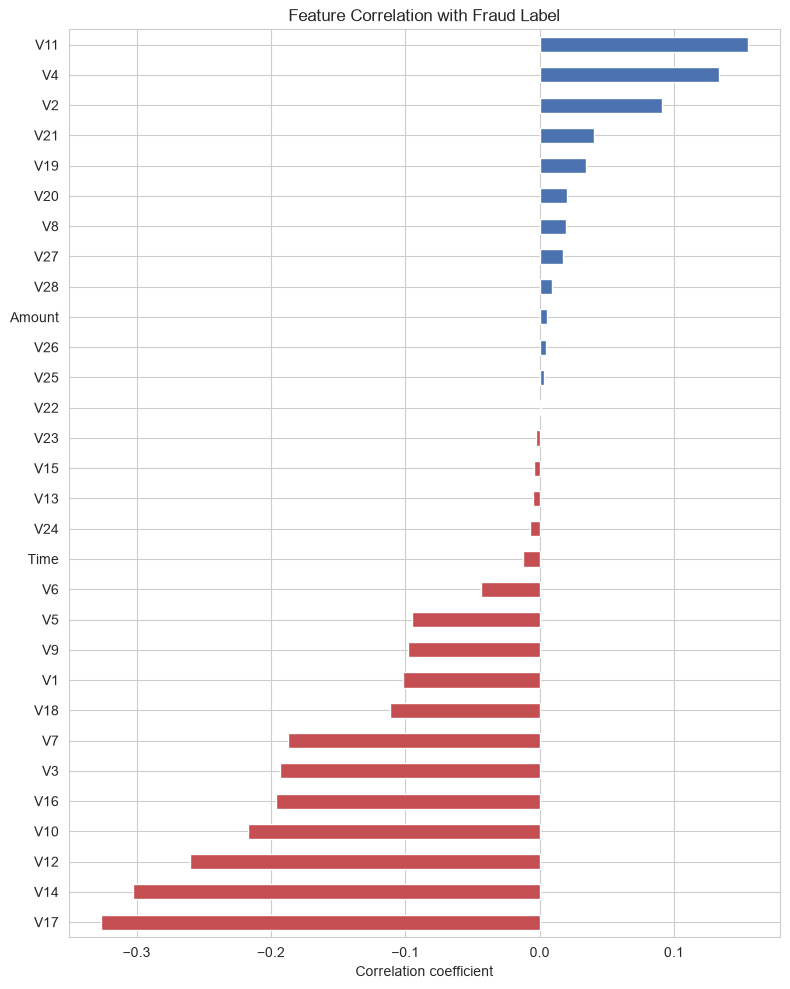

Top 5 positively correlated features:
V11    0.154876
V4     0.133447
V2     0.091289
V21    0.040413
V19    0.034783
Name: Class, dtype: float64

Top 5 negatively correlated features:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [13]:
correlations = df.corr()["Class"].drop("Class").sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
correlations.plot(kind="barh", ax=ax, color=correlations.apply(lambda x: "#C44E52" if x < 0 else "#4C72B0"))
ax.set_title("Feature Correlation with Fraud Label")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

print("Top 5 positively correlated features:")
print(correlations.sort_values(ascending=False).head(5))
print("\nTop 5 negatively correlated features:")
print(correlations.sort_values().head(5))

## Summary

- **Severe class imbalance**: fraud is only ~0.17% of transactions, making accuracy an unreliable metric.
- **Amount patterns differ**: fraudulent transactions show a distinct distribution compared to normal ones, though with significant overlap.
- **No obvious time-based clustering**: fraud appears spread across the observed time window rather than concentrated in specific periods.
- **A handful of PCA features (e.g. the most correlated ones above) show meaningfully stronger relationships with fraud**, which explains why tree-based models like Random Forest can separate the classes effectively.

These findings directly informed the preprocessing and modeling choices in `src/preprocessing.py` and `src/train.py` — particularly the decision to scale `Amount`/`Time` and use `class_weight="balanced"` to address the imbalance.